#

Question: Why is it so hard to find affordable housing in NYC 

In [1]:
import pandas as pd
import seaborn as sns
import plotly.express as px 
import matplotlib.pyplot as plt

al = pd.read_csv("Advertised_Lotteries_on_Housing_Connect_By_Building_20260715.csv")
ah = pd.read_csv("Affordable_Housing_Production_by_Building_20260715.csv")

In [2]:
#Renaming columns for my sanity 
#During Data Wrangling We noticed some columns had an extra space so we cleaned that up as well
# When renaming columns
al = al.rename(columns={
    "Applied Income AMI Category - Extremely Low Income": "Extremely Low Income",
    "Applied Income AMI Category - Very Low Income":"Very Low Income",
    "Applied Income AMI Category - Low Income ": "Low Income",
    "Applied Income AMI Category - Moderate Income": "Moderate Income",
    "Applied Income AMI Category - Middle Income": "Middle Income",
    "Applied Income AMI Category - Above Middle Income": "Above Middle Income"
})

al.columns

Index(['Lottery ID', 'Lottery Name', 'Development Type',
       'Reporting Construction Type', 'Unit Count', 'HPD Building ID',
       'Housing Connect Building ID', 'House Number', 'Street Name', 'Borough',
       'Unit Distribution - Studio', 'Unit Distribution - 1 Bedroom',
       'Unit Distribution - 2 Bedrooms ', 'Unit Distribution - 3 Bedrooms',
       'Unit Distribution - 4 Bedrooms+', 'Extremely Low Income',
       'Very Low Income', 'Low Income', 'Moderate Income', 'Middle Income',
       'Above Middle Income', 'Postcode', 'Latitude', 'Longitude',
       'Community Board', 'Council District', 'BIN', 'BBL',
       'Census Tract (2020)', 'Neighborhood Tabulation Area (NTA) (2020)'],
      dtype='str')

In [3]:
#Cleaning missing values
ah.isna().sum()
ah = ah.dropna(subset=["Extremely Low Income Units"])
ah["Extremely Low Income Units"].describe()

count    1983.000000
mean       28.357035
std        44.139841
min         1.000000
25%         2.000000
50%         8.000000
75%        37.500000
max       429.000000
Name: Extremely Low Income Units, dtype: float64

In [4]:
#advertised lotteries in boroughs for al mainframe 
al["Borough"].value_counts()
al["Borough"].describe()

count     2082
unique       5
top         BK
freq       921
Name: Borough, dtype: object

In [5]:
#adversited Housing in boroughs for ah mainframe
ah["Borough"].value_counts()

Borough
Brooklyn         643
Bronx            586
Manhattan        513
Queens           168
Staten Island     73
Name: count, dtype: int64

In [6]:
#found out the discrepency in the housing being built and the lotteries available
#make a graph about this 
ah["Extremely Low Income Units"].value_counts()
ah["Very Low Income Units"].value_counts()
ah["Low Income Units"].value_counts()

Low Income Units
1.0      210
2.0      171
3.0      110
4.0       66
5.0       46
        ... 
159.0      1
130.0      1
236.0      1
137.0      1
197.0      1
Name: count, Length: 154, dtype: int64

In [7]:
#adversited Housing in boroughs


In [8]:
# Count affordable housing production by borough
production = ah["Borough"].value_counts().sort_index()

# Count Housing Connect lottery buildings by borough
lottery = al["Borough"].value_counts().sort_index()

# Combine into one DataFrame
comparison = pd.DataFrame({
    "Housing Production": production,
    "Lottery Buildings": lottery
}).fillna(0)

comparison

,Housing Production,Lottery Buildings
Borough,,
BK,0.0,921.0
BX,0.0,520.0
Bronx,586.0,0.0
Brooklyn,643.0,0.0
MN,0.0,244.0
Manhattan,513.0,0.0
QN,0.0,381.0
Queens,168.0,0.0
SI,0.0,16.0


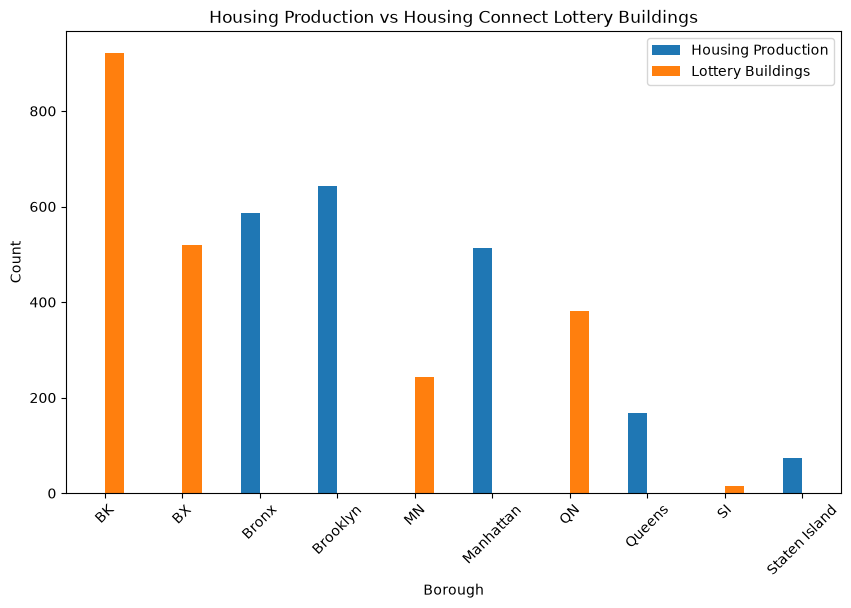

In [14]:
#found out the discrepency in the housing being built and the lotteries available
#make a graph about this 
#This graph compares the number of affordable housing projects with the number of Housing Connect lottery buildings in each borough.
comparison.plot(kind="bar", figsize=(10,6))

plt.title("Housing Production vs Housing Connect Lottery Buildings")
plt.xlabel("Borough")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()


In [10]:
#organize total units by borough


In [11]:
#High Income Units vs Low Income Units Available 

In [12]:
#Which boough has more affordable housing 


In [ ]:
#EVERYTHING SHOULD BE WORKING NOW 